# 04. Model refinement

This notebook focuses on disciplined refinement of the two finalist modeling routes selected in the previous stage of the project.

The notebook does not reopen broad model benchmarking, feature-engineering exploration, or preprocessing recipe selection. Those decisions were fixed in `03_feature_engineering.ipynb` and are treated here as inherited inputs.

The objective of this stage is to refine the finalist routes through targeted hyperparameter optimization, direct post-tuning comparison, probability-quality review, and threshold analysis, so that the project can move from strong candidate models to a final operational selection.

## 1. Title and scope

This notebook focuses on disciplined refinement of the two finalist modeling routes selected in the previous stage of the project.

The notebook does not reopen broad model benchmarking, feature-engineering exploration, or preprocessing recipe selection. Those decisions were fixed in `03_feature_engineering.ipynb` and are treated here as inherited inputs.

The objective of this stage is to refine the finalist routes through targeted hyperparameter optimization, direct post-tuning comparison, probability-quality review, and threshold analysis, so that the project can move from strong candidate models to a final operational selection.

## 2. Inputs, finalist routes, and refinement strategy

This notebook starts from the persisted handoff artifacts created at the end of `03_feature_engineering.ipynb`. The purpose of this design is to preserve continuity between stages while avoiding manual reconstruction of intermediate datasets and selection results.

Two finalist routes enter the refinement stage:

- `hist_gradient_boosting_base` with `hgb_legacy_impute_onehot`
- `catboost_fe` with `catboost_native_missing_cat_token_nan_min`

These routes are already selected and will not be reopened unless a strong empirical reason emerges during refinement.

The refinement strategy is intentionally narrow and disciplined. The notebook will:

1. load the persisted artifacts and reconstruct the finalist modeling paths,
2. tune each finalist route with a focused and defensible search strategy,
3. compare the best tuned versions under a common evaluation framework,
4. briefly review probability quality,
5. analyze decision thresholds for the strongest candidate configurations,
6. and close with a final model selection and minimal interpretation of the winning route.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:

artifact_dir = Path("../artifacts/03_feature_engineering")

X_train_base = pd.read_pickle(artifact_dir / "X_train_base.pkl")
X_test_base = pd.read_pickle(artifact_dir / "X_test_base.pkl")
X_train_fe = pd.read_pickle(artifact_dir / "X_train_fe.pkl")
X_test_fe = pd.read_pickle(artifact_dir / "X_test_fe.pkl")

y_train = pd.read_pickle(artifact_dir / "y_train.pkl")["short_sleep"]
y_test = pd.read_pickle(artifact_dir / "y_test.pkl")["short_sleep"]

hgb_recipe_cv_results = pd.read_csv(artifact_dir / "hgb_recipe_cv_results.csv")
catboost_recipe_cv_results = pd.read_csv(artifact_dir / "catboost_recipe_cv_results.csv")
recipe_selection_summary = pd.read_csv(artifact_dir / "recipe_selection_summary.csv")

with open(artifact_dir / "finalist_route_metadata.json", "r", encoding="utf-8") as f:
    finalist_route_metadata = json.load(f)

loaded_artifacts_overview = pd.DataFrame(
    [
        {"object_name": "X_train_base", "type": type(X_train_base).__name__, "shape": X_train_base.shape},
        {"object_name": "X_test_base", "type": type(X_test_base).__name__, "shape": X_test_base.shape},
        {"object_name": "X_train_fe", "type": type(X_train_fe).__name__, "shape": X_train_fe.shape},
        {"object_name": "X_test_fe", "type": type(X_test_fe).__name__, "shape": X_test_fe.shape},
        {"object_name": "y_train", "type": type(y_train).__name__, "shape": y_train.shape},
        {"object_name": "y_test", "type": type(y_test).__name__, "shape": y_test.shape},
    ]
)

display(loaded_artifacts_overview)
display(recipe_selection_summary)
finalist_route_metadata

,object_name,type,shape
0,X_train_base,DataFrame,"(5830, 21)"
1,X_test_base,DataFrame,"(1458, 21)"
2,X_train_fe,DataFrame,"(5830, 34)"
3,X_test_fe,DataFrame,"(1458, 34)"
4,y_train,Series,"(5830,)"
5,y_test,Series,"(1458,)"


,route,selected_recipe,selection_note
0,hist_gradient_boosting_base,hgb_legacy_impute_onehot,Best overall profile on F1 and balanced accuracy
1,catboost_fe,catboost_native_missing_cat_token_nan_min,Best overall native CatBoost recipe


{'target_name': 'short_sleep',
 'source_notebook': '03_feature_engineering.ipynb',
 'finalist_routes': [{'route_name': 'hist_gradient_boosting_base',
   'feature_space': 'base',
   'selected_recipe': 'hgb_legacy_impute_onehot'},
  {'route_name': 'catboost_fe',
   'feature_space': 'fe',
   'selected_recipe': 'catboost_native_missing_cat_token_nan_min'}],
 'feature_spaces': {'base_columns': ['sleep_hours_weekend',
   'trouble_sleeping',
   'told_doctor_sleep_disorder',
   'snoring_frequency',
   'sex',
   'age_years',
   'race_ethnicity',
   'education_level',
   'income_to_poverty_ratio',
   'weight_kg',
   'height_cm',
   'body_mass_index',
   'waist_circumference_cm',
   'smoked_100_cigarettes_lifetime',
   'alcohol_lifetime_12_drinks',
   'alcohol_frequency',
   'vigorous_activity',
   'moderate_activity',
   'sedentary_minutes',
   'systolic_bp_mean',
   'diastolic_bp_mean'],
  'fe_columns': ['sleep_hours_weekend',
   'age_years',
   'income_to_poverty_ratio',
   'weight_kg',
   'he

## 3. Evaluation framework

This notebook evaluates the finalist routes under a common refinement framework designed to balance classification quality, class-sensitive performance, ranking quality, and probability usefulness.

No single metric is treated as universally sufficient. Instead, the evaluation logic distinguishes between different roles:

- **F1 score** is used as the primary tuning and comparison metric because the task is a binary classification problem in which both false positives and false negatives remain relevant.
- **Balanced accuracy** is used as a class-sensitive control metric to ensure that performance is not being driven disproportionately by one class.
- **ROC AUC** and **average precision** are used to assess ranking quality and probability discrimination before threshold selection.
- **Brier score** is introduced later as a lightweight probability-quality check, since the notebook will also study threshold behavior.

This distinction matters because the notebook is organized in two different decision layers. During tuning and route comparison, the emphasis is on general model quality and discrimination. During threshold analysis, threshold-dependent metrics such as precision, recall, specificity, and confusion-matrix structure regain central importance, because the model is then evaluated as a decision system rather than only as a scoring function.

All refinement comparisons are conducted under a stratified cross-validation scheme to preserve class balance across folds and keep the finalist routes methodologically aligned.

In [3]:
from sklearn.model_selection import StratifiedKFold

refinement_random_state = 42
refinement_n_splits = 5

refinement_cv = StratifiedKFold(
    n_splits=refinement_n_splits,
    shuffle=True,
    random_state=refinement_random_state,
)

refinement_scoring = {
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

primary_refit_metric = "f1"

evaluation_framework_summary = pd.DataFrame(
    [
        {
            "component": "Primary tuning metric",
            "value": primary_refit_metric,
            "role": "Main selection criterion during refinement",
        },
        {
            "component": "Class-sensitive control metric",
            "value": "balanced_accuracy",
            "role": "Performance check across both classes",
        },
        {
            "component": "Ranking / discrimination metrics",
            "value": "roc_auc, average_precision",
            "role": "Model ranking quality before threshold selection",
        },
        {
            "component": "Probability-quality review",
            "value": "brier_score_loss",
            "role": "Lightweight probability usefulness check after tuning",
        },
        {
            "component": "Cross-validation",
            "value": f"StratifiedKFold(n_splits={refinement_n_splits}, shuffle=True, random_state={refinement_random_state})",
            "role": "Common refinement protocol for finalist routes",
        },
    ]
)

display(evaluation_framework_summary)

,component,value,role
0,Primary tuning metric,f1,Main selection criterion during refinement
1,Class-sensitive control metric,balanced_accuracy,Performance check across both classes
2,Ranking / discrimination metrics,"roc_auc, average_precision",Model ranking quality before threshold selection
3,Probability-quality review,brier_score_loss,Lightweight probability usefulness check after...
4,Cross-validation,"StratifiedKFold(n_splits=5, shuffle=True, rand...",Common refinement protocol for finalist routes


## 4. HistGradientBoosting tuning

This section refines the HistGradientBoosting finalist route carried over from the previous notebook.

The selected route combines the **base feature space** with the **`hgb_legacy_impute_onehot`** preprocessing recipe, which outperformed the native alternatives on the main classification-facing metrics during recipe selection.

The purpose of this stage is not to revisit preprocessing decisions, but to optimize the model within the already selected operational route. The search space is therefore limited to hyperparameters that are plausibly influential for this model family, while remaining compact enough to keep the refinement process disciplined and reproducible.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [5]:
hgb_selected_recipe = recipe_selection_summary.loc[
    recipe_selection_summary["route"] == "hist_gradient_boosting_base",
    "selected_recipe",
].iloc[0]

X_train_hgb = X_train_base.copy()
X_test_hgb = X_test_base.copy()

hgb_semantic_categorical_features = [
    "trouble_sleeping",
    "told_doctor_sleep_disorder",
    "snoring_frequency",
    "sex",
    "race_ethnicity",
    "education_level",
    "smoked_100_cigarettes_lifetime",
    "alcohol_lifetime_12_drinks",
    "alcohol_frequency",
    "vigorous_activity",
    "moderate_activity",
]

hgb_categorical_features = [
    col for col in hgb_semantic_categorical_features
    if col in X_train_hgb.columns
]

hgb_numeric_features = [
    col for col in X_train_hgb.columns
    if col not in hgb_categorical_features
]

hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), hgb_numeric_features),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            hgb_categorical_features,
        ),
    ],
    remainder="drop",
)

hgb_base_estimator = HistGradientBoostingClassifier(
    random_state=refinement_random_state
)

hgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", hgb_preprocessor),
        ("model", hgb_base_estimator),
    ]
)

hgb_route_overview = pd.DataFrame(
    [
        {
            "route_name": "hist_gradient_boosting_base",
            "selected_recipe": hgb_selected_recipe,
            "train_rows": X_train_hgb.shape[0],
            "train_columns": X_train_hgb.shape[1],
            "numeric_features": len(hgb_numeric_features),
            "categorical_features": len(hgb_categorical_features),
        }
    ]
)

display(hgb_route_overview)
pd.DataFrame(
    {
        "numeric_features": pd.Series(hgb_numeric_features),
        "categorical_features": pd.Series(hgb_categorical_features),
    }
)

,route_name,selected_recipe,train_rows,train_columns,numeric_features,categorical_features
0,hist_gradient_boosting_base,hgb_legacy_impute_onehot,5830,21,10,11


,numeric_features,categorical_features
0,sleep_hours_weekend,trouble_sleeping
1,age_years,told_doctor_sleep_disorder
2,income_to_poverty_ratio,snoring_frequency
3,weight_kg,sex
4,height_cm,race_ethnicity
5,body_mass_index,education_level
6,waist_circumference_cm,smoked_100_cigarettes_lifetime
7,sedentary_minutes,alcohol_lifetime_12_drinks
8,systolic_bp_mean,alcohol_frequency
9,diastolic_bp_mean,vigorous_activity


### 4.2 HistGradientBoosting tuning strategy

The selected HistGradientBoosting route is refined through a focused hyperparameter search over parameters that are plausibly influential for generalization, regularization, and tree complexity.

The objective is not to exhaust every possible combination, but to explore a disciplined search space that is large enough to improve the finalist route while remaining computationally reasonable and reproducible.

The search is conducted with randomized cross-validated optimization under the common evaluation framework defined earlier in the notebook.

In [6]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

hgb_param_distributions = {
    "model__learning_rate": uniform(0.01, 0.19),
    "model__max_iter": randint(150, 1000),
    "model__max_leaf_nodes": randint(15, 120),
    "model__min_samples_leaf": randint(5, 120),
    "model__l2_regularization": uniform(0.0, 4.0),
    "model__max_bins": randint(64, 255),
}

hgb_random_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_param_distributions,
    n_iter=60,
    scoring=refinement_scoring,
    refit=primary_refit_metric,
    cv=refinement_cv,
    n_jobs=-1,
    verbose=1,
    random_state=refinement_random_state,
    return_train_score=False,
)

hgb_search_space_summary = pd.DataFrame(
    [
        {"parameter": "model__learning_rate", "distribution": "uniform(0.01, 0.19)"},
        {"parameter": "model__max_iter", "distribution": "randint(150, 1000)"},
        {"parameter": "model__max_leaf_nodes", "distribution": "randint(15, 120)"},
        {"parameter": "model__min_samples_leaf", "distribution": "randint(5, 120)"},
        {"parameter": "model__l2_regularization", "distribution": "uniform(0.0, 4.0)"},
        {"parameter": "model__max_bins", "distribution": "randint(64, 255)"},
    ]
)

display(hgb_search_space_summary)

,parameter,distribution
0,model__learning_rate,"uniform(0.01, 0.19)"
1,model__max_iter,"randint(150, 1000)"
2,model__max_leaf_nodes,"randint(15, 120)"
3,model__min_samples_leaf,"randint(5, 120)"
4,model__l2_regularization,"uniform(0.0, 4.0)"
5,model__max_bins,"randint(64, 255)"


### 4.3 HistGradientBoosting randomized search

The randomized search is now executed over the selected HistGradientBoosting route.

The objective is to identify a stronger tuned configuration under the common refinement framework, using F1 score as the refit metric while retaining balanced accuracy, ROC AUC, and average precision for comparative reading.

In [7]:
hgb_random_search.fit(X_train_hgb, y_train)

hgb_best_params = hgb_random_search.best_params_
hgb_best_score = hgb_random_search.best_score_

hgb_cv_results = pd.DataFrame(hgb_random_search.cv_results_)

hgb_tuning_results = (
    hgb_cv_results[
        [
            "rank_test_f1",
            "mean_test_f1",
            "std_test_f1",
            "mean_test_balanced_accuracy",
            "std_test_balanced_accuracy",
            "mean_test_roc_auc",
            "std_test_roc_auc",
            "mean_test_average_precision",
            "std_test_average_precision",
            "param_model__learning_rate",
            "param_model__max_iter",
            "param_model__max_leaf_nodes",
            "param_model__min_samples_leaf",
            "param_model__l2_regularization",
            "param_model__max_bins",
        ]
    ]
    .sort_values(["rank_test_f1", "mean_test_average_precision"], ascending=[True, False])
    .reset_index(drop=True)
    .round(4)
)

hgb_best_result_summary = pd.DataFrame(
    [
        {
            "route": "hist_gradient_boosting_base",
            "selected_recipe": hgb_selected_recipe,
            "best_cv_f1": round(hgb_best_score, 4),
            "best_learning_rate": hgb_best_params["model__learning_rate"],
            "best_max_iter": hgb_best_params["model__max_iter"],
            "best_max_leaf_nodes": hgb_best_params["model__max_leaf_nodes"],
            "best_min_samples_leaf": hgb_best_params["model__min_samples_leaf"],
            "best_l2_regularization": hgb_best_params["model__l2_regularization"],
            "best_max_bins": hgb_best_params["model__max_bins"],
        }
    ]
).round(4)

display(hgb_best_result_summary)
display(hgb_tuning_results.head(10))

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,route,selected_recipe,best_cv_f1,best_learning_rate,best_max_iter,best_max_leaf_nodes,best_min_samples_leaf,best_l2_regularization,best_max_bins
0,hist_gradient_boosting_base,hgb_legacy_impute_onehot,0.6136,0.0765,433,78,101,1.7376,160


,rank_test_f1,mean_test_f1,std_test_f1,mean_test_balanced_accuracy,std_test_balanced_accuracy,mean_test_roc_auc,std_test_roc_auc,mean_test_average_precision,std_test_average_precision,param_model__learning_rate,param_model__max_iter,param_model__max_leaf_nodes,param_model__min_samples_leaf,param_model__l2_regularization,param_model__max_bins
0,1,0.6136,0.0176,0.7127,0.0120,0.7826,0.0138,0.7001,0.0186,0.0765,433,78,101,1.7376,160
1,2,0.6126,0.0253,0.7141,0.0163,0.7976,0.0114,0.7195,0.0204,0.0702,167,39,110,3.4045,191
2,3,0.6112,0.0196,0.7117,0.0130,0.7903,0.0121,0.7069,0.0203,0.0552,429,83,102,3.0465,101
3,4,0.6109,0.0212,0.7107,0.0143,0.7838,0.0137,0.7007,0.0192,0.1125,366,74,113,2.9893,87
4,5,0.6109,0.0284,0.7123,0.0187,0.7917,0.0107,0.7082,0.0192,0.0843,537,16,10,0.6935,113
5,6,0.6103,0.0218,0.7096,0.0153,0.7792,0.0170,0.6954,0.0231,0.1592,403,113,116,3.7425,167
6,7,0.6098,0.0257,0.7111,0.0171,0.7906,0.0125,0.7082,0.0201,0.0327,918,19,94,1.8889,194
7,8,0.6087,0.0230,0.7102,0.0153,0.7897,0.0122,0.7091,0.0185,0.0396,608,102,104,0.6241,138
8,9,0.6085,0.0234,0.7098,0.0154,0.7873,0.0104,0.7046,0.0199,0.0534,495,74,117,2.7831,207
9,10,0.6083,0.0217,0.7090,0.0149,0.7812,0.0160,0.7003,0.0264,0.1073,297,110,75,0.0664,210


### 4.4 First reading of the HistGradientBoosting tuning results

The expanded randomized search produces a meaningful improvement over the untuned HistGradientBoosting finalist route and strengthens the route's position as a serious candidate moving into the final comparison stage.

Under the refinement framework defined earlier in the notebook, the best HistGradientBoosting configuration is the one that maximizes cross-validated F1 score within the selected `hgb_legacy_impute_onehot` route. This tuned configuration therefore becomes the official HGB candidate carried forward under the notebook's primary selection criterion.

At the same time, the tuning results show that nearby configurations can achieve slightly lower F1 while improving balanced accuracy and ranking-oriented metrics such as ROC AUC and average precision. This suggests that the tuned HistGradientBoosting route contains a competitive region of strong solutions rather than a single uniquely dominant point, and it reinforces the value of later post-tuning comparison, probability review, and threshold analysis.

## 5. CatBoost tuning

This section refines the CatBoost finalist route carried over from the previous notebook.

The selected route combines the **feature-engineered feature space** with the **`catboost_native_missing_cat_token_nan_min`** recipe, which provided the strongest overall CatBoost recipe profile during the previous stage.

As in the HistGradientBoosting section, the objective is not to revisit preprocessing or feature-space decisions, but to optimize the model within the already selected operational route. The search therefore focuses on hyperparameters that are plausibly influential for learning dynamics, regularization, and tree complexity while preserving the native categorical and missing-value handling that made this route competitive.

In [8]:
from catboost import CatBoostClassifier

catboost_selected_recipe = recipe_selection_summary.loc[
    recipe_selection_summary["route"] == "catboost_fe",
    "selected_recipe",
].iloc[0]

X_train_catboost = X_train_fe.copy()
X_test_catboost = X_test_fe.copy()

catboost_categorical_features = finalist_route_metadata["catboost_native_recipe_inputs"]["categorical_features"]
catboost_numeric_features = finalist_route_metadata["catboost_native_recipe_inputs"]["numeric_features"]

def prepare_catboost_native_inputs(X_train, X_valid, categorical_features):
    X_train_prepared = X_train.copy()
    X_valid_prepared = X_valid.copy()

    for col in categorical_features:
        X_train_prepared[col] = X_train_prepared[col].astype("object")
        X_valid_prepared[col] = X_valid_prepared[col].astype("object")

        X_train_prepared[col] = X_train_prepared[col].where(
            X_train_prepared[col].notna(), "__missing__"
        )
        X_valid_prepared[col] = X_valid_prepared[col].where(
            X_valid_prepared[col].notna(), "__missing__"
        )

        X_train_prepared[col] = X_train_prepared[col].astype(str)
        X_valid_prepared[col] = X_valid_prepared[col].astype(str)

    return X_train_prepared, X_valid_prepared

catboost_route_overview = pd.DataFrame(
    [
        {
            "route_name": "catboost_fe",
            "selected_recipe": catboost_selected_recipe,
            "train_rows": X_train_catboost.shape[0],
            "train_columns": X_train_catboost.shape[1],
            "numeric_features": len(catboost_numeric_features),
            "categorical_features": len(catboost_categorical_features),
        }
    ]
)

display(catboost_route_overview)
pd.DataFrame(
    {
        "numeric_features": pd.Series(catboost_numeric_features),
        "categorical_features": pd.Series(catboost_categorical_features),
    }
)

,route_name,selected_recipe,train_rows,train_columns,numeric_features,categorical_features
0,catboost_fe,catboost_native_missing_cat_token_nan_min,5830,34,15,19


,numeric_features,categorical_features
0,sleep_hours_weekend,age_band
1,age_years,alcohol_lifetime_12_drinks
2,income_to_poverty_ratio,bmi_category
3,weight_kg,bp_category_accaha2017
4,height_cm,central_obesity_whtR_flag
5,body_mass_index,education_group
6,waist_circumference_cm,education_level
7,sedentary_minutes,frequent_snoring_flag
8,systolic_bp_mean,moderate_activity
9,diastolic_bp_mean,possible_sdb_risk


### 5.2 CatBoost tuning strategy

The selected CatBoost route is refined through a broad but still disciplined hyperparameter search over parameters that are plausibly influential for learning dynamics, tree complexity, regularization, and stochastic behavior.

Unlike the HistGradientBoosting route, CatBoost tuning is executed through a manual fold-by-fold randomized search routine. This preserves compatibility with native categorical handling while keeping the refinement process methodologically aligned with the rest of the notebook.

The search is intentionally demanding enough to give the finalist route a serious optimization opportunity before post-tuning comparison and threshold analysis.

In [9]:
from scipy.stats import randint, uniform

catboost_param_distributions = {
    "learning_rate": uniform(0.01, 0.19),
    "iterations": randint(120, 350),
    "depth": randint(4, 11),
    "l2_leaf_reg": uniform(1.0, 9.0),
    "random_strength": uniform(0.0, 3.0),
    "bagging_temperature": uniform(0.0, 3.0),
    "border_count": randint(64, 255),
}

catboost_n_iter = 15

catboost_search_space_summary = pd.DataFrame(
    [
        {"parameter": "learning_rate", "distribution": "uniform(0.01, 0.19)"},
        {"parameter": "iterations", "distribution": "randint(120, 350)"},
        {"parameter": "depth", "distribution": "randint(4, 11)"},
        {"parameter": "l2_leaf_reg", "distribution": "uniform(1.0, 9.0)"},
        {"parameter": "random_strength", "distribution": "uniform(0.0, 3.0)"},
        {"parameter": "bagging_temperature", "distribution": "uniform(0.0, 3.0)"},
        {"parameter": "border_count", "distribution": "randint(64, 255)"},
    ]
)

display(catboost_search_space_summary)
print("CatBoost randomized search iterations:", catboost_n_iter)

,parameter,distribution
0,learning_rate,"uniform(0.01, 0.19)"
1,iterations,"randint(120, 350)"
2,depth,"randint(4, 11)"
3,l2_leaf_reg,"uniform(1.0, 9.0)"
4,random_strength,"uniform(0.0, 3.0)"
5,bagging_temperature,"uniform(0.0, 3.0)"
6,border_count,"randint(64, 255)"


CatBoost randomized search iterations: 15


### 5.3 Manual randomized tuning for CatBoost

CatBoost is tuned through a manual randomized search routine evaluated fold by fold under stratified cross-validation.

This implementation preserves native categorical and missing-value handling while keeping the refinement stage comparable in spirit to the HistGradientBoosting route. Each sampled configuration is evaluated under the same metric framework, and the search is ranked primarily by cross-validated F1 score.

In [10]:
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
)

from catboost import Pool

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None


def get_positive_class_scores(model, X):
    proba = model.predict_proba(X)
    return proba[:, 1]


catboost_param_list = list(
    ParameterSampler(
        param_distributions=catboost_param_distributions,
        n_iter=catboost_n_iter,
        random_state=refinement_random_state,
    )
)

catboost_cat_feature_indices = [
    X_train_catboost.columns.get_loc(col)
    for col in catboost_categorical_features
]

prepared_catboost_folds = []

for fold_idx, (train_idx, valid_idx) in enumerate(
    refinement_cv.split(X_train_catboost, y_train),
    start=1,
):
    X_train_fold = X_train_catboost.iloc[train_idx]
    X_valid_fold = X_train_catboost.iloc[valid_idx]
    y_train_fold = y_train.iloc[train_idx]
    y_valid_fold = y_train.iloc[valid_idx]

    X_train_prepared, X_valid_prepared = prepare_catboost_native_inputs(
        X_train=X_train_fold,
        X_valid=X_valid_fold,
        categorical_features=catboost_categorical_features,
    )

    train_pool = Pool(
        data=X_train_prepared,
        label=y_train_fold,
        cat_features=catboost_cat_feature_indices,
    )

    valid_pool = Pool(
        data=X_valid_prepared,
        label=y_valid_fold,
        cat_features=catboost_cat_feature_indices,
    )

    prepared_catboost_folds.append(
        {
            "fold": fold_idx,
            "valid_y": y_valid_fold.to_numpy(),
            "valid_pool": valid_pool,
            "train_pool": train_pool,
        }
    )

total_fits = len(catboost_param_list) * len(prepared_catboost_folds)

progress_bar = None
if tqdm is not None:
    progress_bar = tqdm(
        total=total_fits,
        desc="CatBoost tuning",
        unit="fit",
    )
else:
    print(f"CatBoost tuning: 0/{total_fits} fits completed")

catboost_tuning_records = []
completed_fits = 0

for search_idx, params in enumerate(catboost_param_list, start=1):
    f1_scores = []
    balanced_accuracy_scores = []
    roc_auc_scores = []
    average_precision_scores = []

    for fold_data in prepared_catboost_folds:
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            nan_mode="Min",
            random_seed=refinement_random_state,
            verbose=0,
            allow_writing_files=False,
            thread_count=-1,
            **params,
        )

        model.fit(
            fold_data["train_pool"],
            eval_set=fold_data["valid_pool"],
            use_best_model=True,
            early_stopping_rounds=50,
        )

        y_valid_pred = model.predict(fold_data["valid_pool"])
        y_valid_pred = np.asarray(y_valid_pred).astype(int).ravel()
        y_valid_score = get_positive_class_scores(model, fold_data["valid_pool"])
        y_valid_true = fold_data["valid_y"]

        f1_scores.append(f1_score(y_valid_true, y_valid_pred))
        balanced_accuracy_scores.append(
            balanced_accuracy_score(y_valid_true, y_valid_pred)
        )
        roc_auc_scores.append(roc_auc_score(y_valid_true, y_valid_score))
        average_precision_scores.append(
            average_precision_score(y_valid_true, y_valid_score)
        )

        completed_fits += 1
        if progress_bar is not None:
            progress_bar.update(1)
            progress_bar.set_postfix(
                search_iteration=search_idx,
                current_f1=round(float(np.mean(f1_scores)), 4),
            )
        elif completed_fits % len(prepared_catboost_folds) == 0:
            progress_pct = 100 * completed_fits / total_fits
            print(
                f"CatBoost tuning: {completed_fits}/{total_fits} fits "
                f"({progress_pct:.1f}%) completed"
            )

    catboost_tuning_records.append(
        {
            "search_iteration": search_idx,
            "mean_test_f1": np.mean(f1_scores),
            "std_test_f1": np.std(f1_scores, ddof=1),
            "mean_test_balanced_accuracy": np.mean(balanced_accuracy_scores),
            "std_test_balanced_accuracy": np.std(balanced_accuracy_scores, ddof=1),
            "mean_test_roc_auc": np.mean(roc_auc_scores),
            "std_test_roc_auc": np.std(roc_auc_scores, ddof=1),
            "mean_test_average_precision": np.mean(average_precision_scores),
            "std_test_average_precision": np.std(
                average_precision_scores, ddof=1
            ),
            **params,
        }
    )

if progress_bar is not None:
    progress_bar.close()

catboost_tuning_results = (
    pd.DataFrame(catboost_tuning_records)
    .sort_values(
        ["mean_test_f1", "mean_test_average_precision"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
    .round(4)
)

catboost_best_result_summary = pd.DataFrame(
    [
        {
            "route": "catboost_fe",
            "selected_recipe": catboost_selected_recipe,
            "best_cv_f1": catboost_tuning_results.iloc[0]["mean_test_f1"],
            "best_learning_rate": catboost_tuning_results.iloc[0]["learning_rate"],
            "best_iterations": catboost_tuning_results.iloc[0]["iterations"],
            "best_depth": catboost_tuning_results.iloc[0]["depth"],
            "best_l2_leaf_reg": catboost_tuning_results.iloc[0]["l2_leaf_reg"],
            "best_random_strength": catboost_tuning_results.iloc[0]["random_strength"],
            "best_bagging_temperature": catboost_tuning_results.iloc[0]["bagging_temperature"],
            "best_border_count": catboost_tuning_results.iloc[0]["border_count"],
        }
    ]
).round(4)

display(catboost_best_result_summary)
display(catboost_tuning_results.head(10))

CatBoost tuning: 0/75 fits completed
CatBoost tuning: 5/75 fits (6.7%) completed
CatBoost tuning: 10/75 fits (13.3%) completed
CatBoost tuning: 15/75 fits (20.0%) completed
CatBoost tuning: 20/75 fits (26.7%) completed
CatBoost tuning: 25/75 fits (33.3%) completed
CatBoost tuning: 30/75 fits (40.0%) completed
CatBoost tuning: 35/75 fits (46.7%) completed
CatBoost tuning: 40/75 fits (53.3%) completed
CatBoost tuning: 45/75 fits (60.0%) completed
CatBoost tuning: 50/75 fits (66.7%) completed
CatBoost tuning: 55/75 fits (73.3%) completed
CatBoost tuning: 60/75 fits (80.0%) completed
CatBoost tuning: 65/75 fits (86.7%) completed
CatBoost tuning: 70/75 fits (93.3%) completed
CatBoost tuning: 75/75 fits (100.0%) completed


,route,selected_recipe,best_cv_f1,best_learning_rate,best_iterations,best_depth,best_l2_leaf_reg,best_random_strength,best_bagging_temperature,best_border_count
0,catboost_fe,catboost_native_missing_cat_token_nan_min,0.605,0.0827,294.0,9.0,6.5655,2.9497,1.0991,253.0


,search_iteration,mean_test_f1,std_test_f1,mean_test_balanced_accuracy,std_test_balanced_accuracy,mean_test_roc_auc,std_test_roc_auc,mean_test_average_precision,std_test_average_precision,bagging_temperature,border_count,depth,iterations,l2_leaf_reg,learning_rate,random_strength
0,5,0.6050,0.0239,0.7119,0.0145,0.8136,0.0073,0.7293,0.0183,1.0991,253,9,294,6.5655,0.0827,2.9497
1,1,0.6049,0.0152,0.7113,0.0101,0.8121,0.0110,0.7282,0.0244,1.1236,156,10,226,8.0172,0.1234,1.3375
2,13,0.6045,0.0237,0.7120,0.0136,0.8133,0.0075,0.7309,0.0170,1.2702,192,7,255,1.0497,0.1649,2.1206
3,2,0.6026,0.0298,0.7106,0.0177,0.8094,0.0115,0.7193,0.0227,0.2999,151,8,219,2.2858,0.1337,0.1692
4,10,0.6011,0.0178,0.7102,0.0105,0.8161,0.0119,0.7320,0.0218,1.3493,253,7,133,7.5454,0.0720,1.7113
5,15,0.6011,0.0194,0.7104,0.0114,0.8176,0.0091,0.7339,0.0167,2.5501,75,5,152,1.5720,0.0691,0.9755
6,14,0.6006,0.0199,0.7098,0.0116,0.8169,0.0099,0.7361,0.0200,2.1870,96,6,124,9.3367,0.1337,2.7449
7,11,0.5993,0.0220,0.7090,0.0129,0.8145,0.0102,0.7342,0.0150,1.5625,253,8,327,7.7259,0.1125,1.7603
8,12,0.5992,0.0235,0.7091,0.0140,0.8122,0.0102,0.7303,0.0205,2.8958,251,7,160,3.6665,0.0414,0.0469
9,4,0.5983,0.0201,0.7089,0.0117,0.8183,0.0094,0.7355,0.0162,1.5743,152,4,338,6.5067,0.0365,0.8764


### 5.4 First reading of the CatBoost tuning results

The CatBoost tuning results confirm that the route remains highly competitive, but they do not improve the route's F1 profile beyond the strongest CatBoost configuration already observed in the previous stage.

Under the notebook's primary refinement criterion, the best tuned CatBoost configuration is the one that maximizes cross-validated F1 within the selected `catboost_native_missing_cat_token_nan_min` route. This configuration therefore becomes the official tuned CatBoost candidate carried forward into the post-tuning comparison.

At the same time, the tuning table again reveals an internal trade-off between threshold-dependent classification performance and ranking-oriented probability quality. Several nearby configurations achieve slightly lower F1 while improving ROC AUC and average precision, which reinforces the idea that CatBoost should remain an especially relevant candidate in the later probability review and threshold-analysis stages.

## 6. Post-tuning finalist configuration comparison

This section consolidates the four tuned finalist configurations retained after route-specific refinement.

For each finalist route, two configurations are preserved:

- the strongest configuration under the primary operational metric (F1)
- a second configuration with a stronger broader profile across discrimination-oriented metrics

This preserves an important empirical finding from tuning: the configuration that performs best under the main operational metric does not necessarily coincide with the one showing the strongest broader ranking behaviour.

The purpose of this section is not to make the final model decision yet, but to assemble the four shortlisted tuned candidates into a compact comparison table before moving to probability quality review and threshold analysis.

In [11]:
hgb_section6_candidates = (
    hgb_tuning_results.loc[[0, 1]].copy()
    .reset_index(drop=True)
)

hgb_section6_candidates["model_family"] = "hist_gradient_boosting"
hgb_section6_candidates["candidate_role"] = [
    "best_by_f1",
    "stronger_probability_profile",
]

hgb_section6_candidates = hgb_section6_candidates[
    [
        "model_family",
        "candidate_role",
        "rank_test_f1",
        "mean_test_f1",
        "std_test_f1",
        "mean_test_balanced_accuracy",
        "std_test_balanced_accuracy",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "mean_test_average_precision",
        "std_test_average_precision",
        "param_model__learning_rate",
        "param_model__max_iter",
        "param_model__max_leaf_nodes",
        "param_model__min_samples_leaf",
        "param_model__l2_regularization",
        "param_model__max_bins",
    ]
]

catboost_section6_candidates = (
    catboost_tuning_results.loc[[0, 5]].copy()
    .reset_index(drop=True)
)

catboost_section6_candidates["model_family"] = "catboost"
catboost_section6_candidates["candidate_role"] = [
    "best_by_f1",
    "stronger_probability_profile",
]

catboost_section6_candidates = catboost_section6_candidates[
    [
        "model_family",
        "candidate_role",
        "search_iteration",
        "mean_test_f1",
        "std_test_f1",
        "mean_test_balanced_accuracy",
        "std_test_balanced_accuracy",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "mean_test_average_precision",
        "std_test_average_precision",
        "bagging_temperature",
        "border_count",
        "depth",
        "iterations",
        "l2_leaf_reg",
        "learning_rate",
        "random_strength",
    ]
]

finalist_config_comparison = pd.concat(
    [
        hgb_section6_candidates,
        catboost_section6_candidates,
    ],
    axis=0,
    ignore_index=True,
)

finalist_config_comparison[
    [
        "model_family",
        "candidate_role",
        "mean_test_f1",
        "mean_test_balanced_accuracy",
        "mean_test_roc_auc",
        "mean_test_average_precision",
    ]
]

,model_family,candidate_role,mean_test_f1,mean_test_balanced_accuracy,mean_test_roc_auc,mean_test_average_precision
0,hist_gradient_boosting,best_by_f1,0.6136,0.7127,0.7826,0.7001
1,hist_gradient_boosting,stronger_probability_profile,0.6126,0.7141,0.7976,0.7195
2,catboost,best_by_f1,0.6050,0.7119,0.8136,0.7293
3,catboost,stronger_probability_profile,0.6011,0.7104,0.8176,0.7339


The finalist comparison confirms that both model families exhibit the same tuning pattern: the strongest F1 configuration is not exactly the same as the one with the strongest broader discrimination profile.

For HistGradientBoosting, the second retained configuration remains very close in F1 while improving balanced accuracy, ROC AUC, and average precision. For CatBoost, the same pattern appears again, with a second candidate offering stronger ranking-oriented behaviour at only a small operational F1 cost.

These four tuned configurations are therefore retained for the next stages: probability quality review and threshold analysis.

The shortlisted tuned candidates are stored explicitly so they can be reused consistently in the next sections. At this stage, what is retained is not a set of final fitted models, but a stable definition of each finalist configuration, including its model family, selection role, and tuned hyperparameters.

In [12]:
def row_to_hgb_params(row):
    return {
        "learning_rate": row["param_model__learning_rate"],
        "max_iter": int(row["param_model__max_iter"]),
        "max_leaf_nodes": int(row["param_model__max_leaf_nodes"]),
        "min_samples_leaf": int(row["param_model__min_samples_leaf"]),
        "l2_regularization": row["param_model__l2_regularization"],
        "max_bins": int(row["param_model__max_bins"]),
    }

def row_to_catboost_params(row):
    return {
        "bagging_temperature": row["bagging_temperature"],
        "border_count": int(row["border_count"]),
        "depth": int(row["depth"]),
        "iterations": int(row["iterations"]),
        "l2_leaf_reg": row["l2_leaf_reg"],
        "learning_rate": row["learning_rate"],
        "random_strength": row["random_strength"],
    }

def to_python_scalar(value):
    return value.item() if hasattr(value, "item") else value

def normalize_param_dict(param_dict):
    return {
        key: to_python_scalar(value)
        for key, value in param_dict.items()
    }

hgb_best_row = hgb_section6_candidates.loc[
    hgb_section6_candidates["candidate_role"] == "best_by_f1"
].iloc[0]

hgb_prob_row = hgb_section6_candidates.loc[
    hgb_section6_candidates["candidate_role"] == "stronger_probability_profile"
].iloc[0]

catboost_best_row = catboost_section6_candidates.loc[
    catboost_section6_candidates["candidate_role"] == "best_by_f1"
].iloc[0]

catboost_prob_row = catboost_section6_candidates.loc[
    catboost_section6_candidates["candidate_role"] == "stronger_probability_profile"
].iloc[0]

finalist_candidate_configs = {
    "hgb_best_by_f1": {
        "model_family": "hist_gradient_boosting",
        "candidate_role": "best_by_f1",
        "feature_space": "base",
        "recipe": "hgb_legacy_impute_onehot",
        "params": row_to_hgb_params(hgb_best_row),
    },
    "hgb_stronger_probability_profile": {
        "model_family": "hist_gradient_boosting",
        "candidate_role": "stronger_probability_profile",
        "feature_space": "base",
        "recipe": "hgb_legacy_impute_onehot",
        "params": row_to_hgb_params(hgb_prob_row),
    },
    "catboost_best_by_f1": {
        "model_family": "catboost",
        "candidate_role": "best_by_f1",
        "feature_space": "fe",
        "recipe": "catboost_native_missing_cat_token_nan_min",
        "params": row_to_catboost_params(catboost_best_row),
    },
    "catboost_stronger_probability_profile": {
        "model_family": "catboost",
        "candidate_role": "stronger_probability_profile",
        "feature_space": "fe",
        "recipe": "catboost_native_missing_cat_token_nan_min",
        "params": row_to_catboost_params(catboost_prob_row),
    },
}

for candidate_name, candidate_cfg in finalist_candidate_configs.items():
    candidate_cfg["params"] = normalize_param_dict(candidate_cfg["params"])

finalist_candidate_configs

{'hgb_best_by_f1': {'model_family': 'hist_gradient_boosting',
  'candidate_role': 'best_by_f1',
  'feature_space': 'base',
  'recipe': 'hgb_legacy_impute_onehot',
  'params': {'learning_rate': 0.0765,
   'max_iter': 433,
   'max_leaf_nodes': 78,
   'min_samples_leaf': 101,
   'l2_regularization': 1.7376,
   'max_bins': 160}},
 'hgb_stronger_probability_profile': {'model_family': 'hist_gradient_boosting',
  'candidate_role': 'stronger_probability_profile',
  'feature_space': 'base',
  'recipe': 'hgb_legacy_impute_onehot',
  'params': {'learning_rate': 0.0702,
   'max_iter': 167,
   'max_leaf_nodes': 39,
   'min_samples_leaf': 110,
   'l2_regularization': 3.4045,
   'max_bins': 191}},
 'catboost_best_by_f1': {'model_family': 'catboost',
  'candidate_role': 'best_by_f1',
  'feature_space': 'fe',
  'recipe': 'catboost_native_missing_cat_token_nan_min',
  'params': {'bagging_temperature': 1.0991,
   'border_count': 253,
   'depth': 9,
   'iterations': 294,
   'l2_leaf_reg': 6.5655,
   'lear

## 7. Probability quality review

After consolidating the four tuned finalist configurations, the next step is to review their probability behaviour on the holdout test split.

The objective of this section is not yet to optimize classification thresholds, but to assess whether the shortlisted candidates differ meaningfully in probability quality once refitted on the corresponding training data.

The first step is therefore to reconstruct each finalist candidate, fit it on its designated training space, and generate holdout predicted probabilities for downstream comparison.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from catboost import CatBoostClassifier

RANDOM_STATE = 42

hgb_semantic_categorical_cols = [
    "trouble_sleeping",
    "told_doctor_sleep_disorder",
    "snoring_frequency",
    "sex",
    "race_ethnicity",
    "education_level",
    "smoked_100_cigarettes_lifetime",
    "alcohol_lifetime_12_drinks",
    "alcohol_frequency",
    "vigorous_activity",
    "moderate_activity",
]

hgb_semantic_numeric_cols = [
    col for col in X_train_base.columns
    if col not in hgb_semantic_categorical_cols
]

catboost_recipe_inputs = finalist_route_metadata["catboost_native_recipe_inputs"]
catboost_categorical_cols = catboost_recipe_inputs["categorical_features"]
catboost_numeric_cols = catboost_recipe_inputs["numeric_features"]

In [16]:
def build_hgb_legacy_pipeline(params, categorical_cols, numeric_cols, random_state):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_cols),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )

    model = HistGradientBoostingClassifier(
        random_state=random_state,
        **params,
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

def build_catboost_native_model(params, random_state):
    return CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="F1",
        random_state=random_state,
        verbose=0,
        **params,
    )

def get_feature_space_data(feature_space):
    if feature_space == "base":
        return X_train_base, X_test_base
    if feature_space == "fe":
        return X_train_fe, X_test_fe
    raise ValueError(f"Unsupported feature_space: {feature_space}")

def prepare_catboost_native_data(X, categorical_cols, numeric_cols):
    X_prepared = X.copy()

    X_prepared[categorical_cols] = (
        X_prepared[categorical_cols]
        .astype("object")
        .where(X_prepared[categorical_cols].notna(), "nan")
        .astype(str)
    )

    return X_prepared[categorical_cols + numeric_cols]

def build_finalist_estimator(candidate_cfg):
    model_family = candidate_cfg["model_family"]
    recipe = candidate_cfg["recipe"]
    params = candidate_cfg["params"]

    if model_family == "hist_gradient_boosting":
        if recipe != "hgb_legacy_impute_onehot":
            raise ValueError(f"Unsupported HGB recipe: {recipe}")

        return build_hgb_legacy_pipeline(
            params=params,
            categorical_cols=hgb_semantic_categorical_cols,
            numeric_cols=hgb_semantic_numeric_cols,
            random_state=RANDOM_STATE,
        )

    if model_family == "catboost":
        if recipe != "catboost_native_missing_cat_token_nan_min":
            raise ValueError(f"Unsupported CatBoost recipe: {recipe}")

        return build_catboost_native_model(
            params=params,
            random_state=RANDOM_STATE,
        )

    raise ValueError(f"Unsupported model_family: {model_family}")

fitted_finalist_models = {}
finalist_test_probabilities = {}
finalist_reconstruction_summary = []

for candidate_name, candidate_cfg in finalist_candidate_configs.items():
    feature_space = candidate_cfg["feature_space"]
    model_family = candidate_cfg["model_family"]

    X_train_current, X_test_current = get_feature_space_data(feature_space)
    estimator = build_finalist_estimator(candidate_cfg)

    if model_family == "catboost":
        X_train_model = prepare_catboost_native_data(
            X_train_current,
            categorical_cols=catboost_categorical_cols,
            numeric_cols=catboost_numeric_cols,
        )
        X_test_model = prepare_catboost_native_data(
            X_test_current,
            categorical_cols=catboost_categorical_cols,
            numeric_cols=catboost_numeric_cols,
        )

        estimator.fit(
            X_train_model,
            y_train,
            cat_features=catboost_categorical_cols,
        )
    else:
        X_train_model = X_train_current
        X_test_model = X_test_current
        estimator.fit(X_train_model, y_train)

    y_test_proba = estimator.predict_proba(X_test_model)[:, 1]

    fitted_finalist_models[candidate_name] = estimator
    finalist_test_probabilities[candidate_name] = y_test_proba

    finalist_reconstruction_summary.append(
        {
            "candidate_name": candidate_name,
            "model_family": model_family,
            "candidate_role": candidate_cfg["candidate_role"],
            "feature_space": feature_space,
            "recipe": candidate_cfg["recipe"],
            "n_train_rows": X_train_model.shape[0],
            "n_test_rows": X_test_model.shape[0],
            "n_features": X_train_model.shape[1],
        }
    )

finalist_reconstruction_summary = pd.DataFrame(finalist_reconstruction_summary)
finalist_reconstruction_summary

,candidate_name,model_family,candidate_role,feature_space,recipe,n_train_rows,n_test_rows,n_features
0,hgb_best_by_f1,hist_gradient_boosting,best_by_f1,base,hgb_legacy_impute_onehot,5830,1458,21
1,hgb_stronger_probability_profile,hist_gradient_boosting,stronger_probability_profile,base,hgb_legacy_impute_onehot,5830,1458,21
2,catboost_best_by_f1,catboost,best_by_f1,fe,catboost_native_missing_cat_token_nan_min,5830,1458,34
3,catboost_stronger_probability_profile,catboost,stronger_probability_profile,fe,catboost_native_missing_cat_token_nan_min,5830,1458,34


### 7.1 Compact probability quality comparison

This subsection compares the four shortlisted tuned candidates using probability-oriented holdout metrics.

The goal is not yet to optimize decision thresholds, but to examine whether the retained candidates differ meaningfully in probability quality and ranking behaviour on the test split.

A compact comparison is used here based on Brier score, ROC AUC, and average precision.

In [17]:
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

probability_quality_rows = []

for candidate_name, candidate_cfg in finalist_candidate_configs.items():
    y_test_proba = finalist_test_probabilities[candidate_name]

    probability_quality_rows.append(
        {
            "candidate_name": candidate_name,
            "model_family": candidate_cfg["model_family"],
            "candidate_role": candidate_cfg["candidate_role"],
            "feature_space": candidate_cfg["feature_space"],
            "recipe": candidate_cfg["recipe"],
            "brier_score": brier_score_loss(y_test, y_test_proba),
            "roc_auc_test": roc_auc_score(y_test, y_test_proba),
            "average_precision_test": average_precision_score(y_test, y_test_proba),
            "mean_predicted_probability": y_test_proba.mean(),
            "std_predicted_probability": y_test_proba.std(),
        }
    )

probability_quality_review = (
    pd.DataFrame(probability_quality_rows)
    .sort_values(
        by=["brier_score", "roc_auc_test", "average_precision_test"],
        ascending=[True, False, False],
    )
    .reset_index(drop=True)
)

probability_quality_review

,candidate_name,model_family,candidate_role,feature_space,recipe,brier_score,roc_auc_test,average_precision_test,mean_predicted_probability,std_predicted_probability
0,catboost_stronger_probability_profile,catboost,stronger_probability_profile,fe,catboost_native_missing_cat_token_nan_min,0.151154,0.822487,0.738801,0.340222,0.266604
1,catboost_best_by_f1,catboost,best_by_f1,fe,catboost_native_missing_cat_token_nan_min,0.152691,0.820660,0.737449,0.333327,0.289628
2,hgb_stronger_probability_profile,hist_gradient_boosting,stronger_probability_profile,base,hgb_legacy_impute_onehot,0.158854,0.800688,0.730143,0.343790,0.289937
3,hgb_best_by_f1,hist_gradient_boosting,best_by_f1,base,hgb_legacy_impute_onehot,0.168597,0.796982,0.719880,0.332093,0.330958


The probability-oriented holdout comparison shows a clear pattern. CatBoost outperforms HistGradientBoosting across all three probability-focused metrics, with lower Brier score and higher ROC AUC and average precision.

Within both model families, the candidate previously retained for its stronger broader probability profile also remains stronger on the holdout test split. This provides useful confirmation that the distinction introduced at the end of tuning was meaningful rather than arbitrary.

At this stage, the probability review strengthens the CatBoost route, particularly the stronger-probability-profile candidate. However, the final model decision is still deferred until threshold analysis, where operational behaviour under different decision cutoffs will be examined explicitly.

### 7.2 Calibration snapshot

To complement the compact probability metric comparison, this subsection adds a lightweight calibration view of the four shortlisted candidates on the holdout test split.

The goal is not to perform full calibration modeling, but simply to inspect whether predicted probabilities appear broadly aligned with observed event frequencies before moving to threshold analysis.

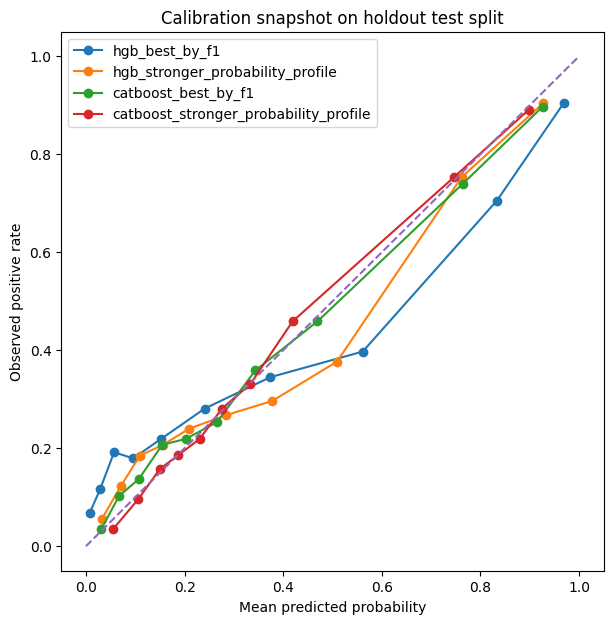

In [18]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

for candidate_name, y_test_proba in finalist_test_probabilities.items():
    frac_pos, mean_pred = calibration_curve(
        y_test,
        y_test_proba,
        n_bins=10,
        strategy="quantile",
    )
    plt.plot(mean_pred, frac_pos, marker="o", label=candidate_name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Calibration snapshot on holdout test split")
plt.legend()
plt.show()

## 8. Threshold analysis

After reviewing holdout probability quality, the next step is to evaluate how the shortlisted finalist configurations behave under different decision thresholds.

This section shifts the focus from ranking quality to operational classification behaviour. The aim is to examine the precision–recall trade-off and related threshold-dependent metrics before making the final model selection.

The analysis is conducted on the holdout test split using the predicted probabilities generated in the previous section.

### 8.1 Local threshold sweep

This subsection evaluates the four shortlisted candidates across a fine-grained threshold grid centred on the most plausible operational range.

Rather than using a coarse threshold sweep, a local grid is preferred here in order to identify more precisely where each candidate reaches its best F1 trade-off and how recall, specificity, and balanced accuracy evolve around that region.

In [19]:
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
import numpy as np

threshold_grid = np.round(np.arange(0.45, 0.651, 0.01), 2)

threshold_analysis_rows = []

for candidate_name, candidate_cfg in finalist_candidate_configs.items():
    y_test_proba = finalist_test_probabilities[candidate_name]

    for threshold in threshold_grid:
        y_pred = (y_test_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp)

        threshold_analysis_rows.append(
            {
                "candidate_name": candidate_name,
                "model_family": candidate_cfg["model_family"],
                "candidate_role": candidate_cfg["candidate_role"],
                "threshold": threshold,
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "f1": f1_score(y_test, y_pred, zero_division=0),
                "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                "specificity": specificity,
                "tp": tp,
                "fp": fp,
                "tn": tn,
                "fn": fn,
            }
        )

threshold_analysis_table = pd.DataFrame(threshold_analysis_rows)
threshold_analysis_table

,candidate_name,model_family,candidate_role,threshold,precision,recall,f1,balanced_accuracy,specificity,tp,fp,tn,fn
0,hgb_best_by_f1,hist_gradient_boosting,best_by_f1,0.45,0.667426,0.589537,0.626068,0.718806,0.848075,293,146,815,204
1,hgb_best_by_f1,hist_gradient_boosting,best_by_f1,0.46,0.676815,0.581489,0.625541,0.718944,0.856400,289,138,823,208
2,hgb_best_by_f1,hist_gradient_boosting,best_by_f1,0.47,0.681818,0.573441,0.622951,0.717522,0.861602,285,133,828,212
3,hgb_best_by_f1,hist_gradient_boosting,best_by_f1,0.48,0.685366,0.565392,0.619625,0.715579,0.865765,281,129,832,216
4,hgb_best_by_f1,hist_gradient_boosting,best_by_f1,0.49,0.694030,0.561368,0.620690,0.716688,0.872008,279,123,838,218
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,catboost_stronger_probability_profile,catboost,stronger_probability_profile,0.61,0.845283,0.450704,0.587927,0.704020,0.957336,224,41,920,273
80,catboost_stronger_probability_profile,catboost,stronger_probability_profile,0.62,0.850575,0.446680,0.585752,0.703049,0.959417,222,39,922,275
81,catboost_stronger_probability_profile,catboost,stronger_probability_profile,0.63,0.853282,0.444668,0.584656,0.702563,0.960458,221,38,923,276
82,catboost_stronger_probability_profile,catboost,stronger_probability_profile,0.64,0.853282,0.444668,0.584656,0.702563,0.960458,221,38,923,276


In [20]:
best_thresholds_by_f1 = (
    threshold_analysis_table
    .sort_values(["candidate_name", "f1", "balanced_accuracy"], ascending=[True, False, False])
    .groupby("candidate_name", as_index=False)
    .first()
    .sort_values(["f1", "balanced_accuracy"], ascending=False)
    .reset_index(drop=True)
)

best_thresholds_by_f1

,candidate_name,model_family,candidate_role,threshold,precision,recall,f1,balanced_accuracy,specificity,tp,fp,tn,fn
0,hgb_stronger_probability_profile,hist_gradient_boosting,stronger_probability_profile,0.48,0.724936,0.567404,0.636569,0.728031,0.888658,282,107,854,215
1,catboost_best_by_f1,catboost,best_by_f1,0.45,0.735450,0.559356,0.635429,0.727649,0.895942,278,100,861,219
2,hgb_best_by_f1,hist_gradient_boosting,best_by_f1,0.52,0.722078,0.559356,0.630385,0.724007,0.888658,278,107,854,219
3,catboost_stronger_probability_profile,catboost,stronger_probability_profile,0.45,0.792049,0.521127,0.628641,0.725184,0.929240,259,68,893,238


### 8.2 Focused threshold comparison

After the local threshold sweep, the next step is to focus on the most operationally relevant threshold region for each shortlisted candidate.

Rather than inspecting the full threshold grid again, this subsection narrows the comparison to the best local F1 threshold per candidate and its immediate neighbourhood. This makes it easier to assess local stability and to distinguish between genuinely robust operating points and narrow threshold-specific peaks before moving to the final fine-grained refinement stage.

In [21]:
best_threshold_map = (
    threshold_analysis_table
    .sort_values(
        ["candidate_name", "f1", "balanced_accuracy"],
        ascending=[True, False, False],
    )
    .groupby("candidate_name")["threshold"]
    .first()
    .to_dict()
)

focused_threshold_rows = []

for candidate_name, best_threshold in best_threshold_map.items():
    candidate_slice = threshold_analysis_table[
        threshold_analysis_table["candidate_name"] == candidate_name
    ].copy()

    candidate_slice = candidate_slice[
        candidate_slice["threshold"].isin(
            [
                round(best_threshold - 0.01, 2),
                best_threshold,
                round(best_threshold + 0.01, 2),
            ]
        )
    ]

    focused_threshold_rows.append(candidate_slice)

focused_threshold_comparison = (
    pd.concat(focused_threshold_rows, axis=0)
    .sort_values(["candidate_name", "threshold"])
    .reset_index(drop=True)
)

focused_threshold_comparison

,candidate_name,model_family,candidate_role,threshold,precision,recall,f1,balanced_accuracy,specificity,tp,fp,tn,fn
0,catboost_best_by_f1,catboost,best_by_f1,0.45,0.735450,0.559356,0.635429,0.727649,0.895942,278,100,861,219
1,catboost_best_by_f1,catboost,best_by_f1,0.46,0.746594,0.551308,0.634259,0.727267,0.903226,274,93,868,223
2,catboost_stronger_probability_profile,catboost,stronger_probability_profile,0.45,0.792049,0.521127,0.628641,0.725184,0.929240,259,68,893,238
3,catboost_stronger_probability_profile,catboost,stronger_probability_profile,0.46,0.793750,0.511066,0.621787,0.721194,0.931322,254,66,895,243
4,hgb_best_by_f1,hist_gradient_boosting,best_by_f1,0.51,0.715385,0.561368,0.629087,0.722932,0.884495,279,111,850,218
5,hgb_best_by_f1,hist_gradient_boosting,best_by_f1,0.52,0.722078,0.559356,0.630385,0.724007,0.888658,278,107,854,219
6,hgb_best_by_f1,hist_gradient_boosting,best_by_f1,0.53,0.725131,0.557344,0.630262,0.724041,0.890739,277,105,856,220
7,hgb_stronger_probability_profile,hist_gradient_boosting,stronger_probability_profile,0.47,0.708229,0.571429,0.632517,0.724840,0.878252,284,117,844,213
8,hgb_stronger_probability_profile,hist_gradient_boosting,stronger_probability_profile,0.48,0.724936,0.567404,0.636569,0.728031,0.888658,282,107,854,215
9,hgb_stronger_probability_profile,hist_gradient_boosting,stronger_probability_profile,0.49,0.732283,0.561368,0.635535,0.727614,0.893861,279,102,859,218


The focused threshold comparison sharpens the shortlist further.

Within the HistGradientBoosting route, the stronger-probability-profile candidate clearly dominates the F1-selected alternative, showing both a higher local F1 peak and a stronger overall operating profile around the relevant threshold region. Within the CatBoost route, the best-by-F1 candidate becomes the stronger operational representative, while the stronger-probability-profile alternative remains more conservative and less competitive under the project’s primary operational criterion.

This reduces the shortlist to two practically relevant contenders:

- `hgb_stronger_probability_profile`
- `catboost_best_by_f1`

At this stage, the comparison is no longer about broad family-level exploration, but about narrowing the final decision to the strongest HGB operating point and the strongest CatBoost operating point before fine-grained threshold refinement.

### 8.3 Fine-grained threshold refinement

After the local threshold sweep identified the two strongest operational contenders, a final fine-grained threshold refinement is performed in a narrow region around their best candidate-specific cutoffs.

This step is intentionally limited to the two final contenders and is used only to check whether a slightly more precise operating point changes the final ranking in a meaningful way.

In [22]:
fine_threshold_contenders = [
    "hgb_stronger_probability_profile",
    "catboost_best_by_f1",
]

fine_threshold_grid = np.round(np.arange(0.43, 0.501, 0.005), 3)

fine_threshold_rows = []

for candidate_name in fine_threshold_contenders:
    candidate_cfg = finalist_candidate_configs[candidate_name]
    y_test_proba = finalist_test_probabilities[candidate_name]

    for threshold in fine_threshold_grid:
        y_pred = (y_test_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp)

        fine_threshold_rows.append(
            {
                "candidate_name": candidate_name,
                "model_family": candidate_cfg["model_family"],
                "candidate_role": candidate_cfg["candidate_role"],
                "threshold": threshold,
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "f1": f1_score(y_test, y_pred, zero_division=0),
                "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                "specificity": specificity,
                "tp": tp,
                "fp": fp,
                "tn": tn,
                "fn": fn,
            }
        )

fine_threshold_analysis = (
    pd.DataFrame(fine_threshold_rows)
    .sort_values(
        ["candidate_name", "threshold"],
        ascending=True,
    )
    .reset_index(drop=True)
)

fine_threshold_analysis

,candidate_name,model_family,candidate_role,threshold,precision,recall,f1,balanced_accuracy,specificity,tp,fp,tn,fn
0,catboost_best_by_f1,catboost,best_by_f1,0.430,0.727273,0.579477,0.645017,0.733547,0.887617,288,108,853,209
1,catboost_best_by_f1,catboost,best_by_f1,0.435,0.735751,0.571429,0.643262,0.732645,0.893861,284,102,859,213
2,catboost_best_by_f1,catboost,best_by_f1,0.440,0.737662,0.571429,0.643991,0.733165,0.894901,284,101,860,213
3,catboost_best_by_f1,catboost,best_by_f1,0.445,0.736292,0.567404,0.640909,0.731153,0.894901,282,101,860,215
4,catboost_best_by_f1,catboost,best_by_f1,0.450,0.735450,0.559356,0.635429,0.727649,0.895942,278,100,861,219
5,catboost_best_by_f1,catboost,best_by_f1,0.455,0.741935,0.555332,0.635213,0.727718,0.900104,276,96,865,221
6,catboost_best_by_f1,catboost,best_by_f1,0.460,0.746594,0.551308,0.634259,0.727267,0.903226,274,93,868,223
7,catboost_best_by_f1,catboost,best_by_f1,0.465,0.749311,0.547284,0.632558,0.726295,0.905307,272,91,870,225
8,catboost_best_by_f1,catboost,best_by_f1,0.470,0.750693,0.545272,0.631702,0.725810,0.906348,271,90,871,226
9,catboost_best_by_f1,catboost,best_by_f1,0.475,0.757746,0.541247,0.631455,0.725879,0.910510,269,86,875,228


In [23]:
fine_threshold_best = (
    fine_threshold_analysis
    .sort_values(
        ["candidate_name", "f1", "balanced_accuracy", "precision"],
        ascending=[True, False, False, False],
    )
    .groupby("candidate_name", as_index=False)
    .first()
    .sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    )
    .reset_index(drop=True)
)

fine_threshold_best

,candidate_name,model_family,candidate_role,threshold,precision,recall,f1,balanced_accuracy,specificity,tp,fp,tn,fn
0,catboost_best_by_f1,catboost,best_by_f1,0.43,0.727273,0.579477,0.645017,0.733547,0.887617,288,108,853,209
1,hgb_stronger_probability_profile,hist_gradient_boosting,stronger_probability_profile,0.48,0.724936,0.567404,0.636569,0.728031,0.888658,282,107,854,215


### 8.4 Final thresholded contender comparison

After the fine-grained threshold refinement, the threshold analysis is reduced to the two strongest final contenders at their selected operating points.

This comparison summarizes the best refined threshold identified for the strongest HGB candidate and the strongest CatBoost candidate, providing a compact operational head-to-head view before final model selection.

In [24]:
final_threshold_contenders = [
    "hgb_stronger_probability_profile",
    "catboost_best_by_f1",
]

final_threshold_comparison = (
    fine_threshold_analysis[
        fine_threshold_analysis["candidate_name"].isin(final_threshold_contenders)
    ]
    .sort_values(
        ["candidate_name", "f1", "balanced_accuracy", "precision"],
        ascending=[True, False, False, False],
    )
    .groupby("candidate_name", as_index=False)
    .first()
    .sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    )
    .reset_index(drop=True)
)

final_threshold_comparison

,candidate_name,model_family,candidate_role,threshold,precision,recall,f1,balanced_accuracy,specificity,tp,fp,tn,fn
0,catboost_best_by_f1,catboost,best_by_f1,0.43,0.727273,0.579477,0.645017,0.733547,0.887617,288,108,853,209
1,hgb_stronger_probability_profile,hist_gradient_boosting,stronger_probability_profile,0.48,0.724936,0.567404,0.636569,0.728031,0.888658,282,107,854,215


The final thresholded comparison shows that the refined CatBoost operating point overtakes the strongest HGB alternative on the project’s main operational criteria.

After fine-grained threshold refinement, `catboost_best_by_f1` achieves the highest F1 and the highest balanced accuracy among the two final contenders. It also retains a slightly stronger precision and recall profile, while the HGB contender remains very competitive and delivers nearly identical specificity.

This result completes the threshold analysis and supports carrying `catboost_best_by_f1` forward as the final selected model in the next section.

## 9. Final model selection

The final selected model is the threshold-tuned `catboost_best_by_f1` configuration.

CatBoost had already shown the strongest probability-oriented behaviour during the probability review stage. After the final fine-grained threshold refinement restricted to the two strongest operational contenders, the selected CatBoost configuration also achieved the strongest overall operational profile on the holdout evaluation split.

The table below summarizes the selected model specification and its final operating point.

In [25]:
selected_candidate_name = "catboost_best_by_f1"
selected_threshold = 0.43

In [26]:
selected_model_spec = pd.Series(
    {
        "candidate_name": selected_candidate_name,
        "model_family": "catboost",
        "feature_space": finalist_candidate_configs[selected_candidate_name]["feature_space"],
        "recipe": finalist_candidate_configs[selected_candidate_name]["recipe"],
        "categorical_handling": "native_catboost_with_explicit_nan_token",
        "learning_rate": finalist_candidate_configs[selected_candidate_name]["params"]["learning_rate"],
        "iterations": finalist_candidate_configs[selected_candidate_name]["params"]["iterations"],
        "depth": finalist_candidate_configs[selected_candidate_name]["params"]["depth"],
        "l2_leaf_reg": finalist_candidate_configs[selected_candidate_name]["params"]["l2_leaf_reg"],
        "random_strength": finalist_candidate_configs[selected_candidate_name]["params"]["random_strength"],
        "bagging_temperature": finalist_candidate_configs[selected_candidate_name]["params"]["bagging_temperature"],
        "border_count": finalist_candidate_configs[selected_candidate_name]["params"]["border_count"],
    },
    name="selected_model",
).to_frame()

selected_model_spec

,selected_model
candidate_name,catboost_best_by_f1
model_family,catboost
feature_space,fe
recipe,catboost_native_missing_cat_token_nan_min
categorical_handling,native_catboost_with_explicit_nan_token
learning_rate,0.0827
iterations,294
depth,9
l2_leaf_reg,6.5655
random_strength,2.9497


In [27]:
selected_operating_point = (
    fine_threshold_analysis[
        (fine_threshold_analysis["candidate_name"] == selected_candidate_name)
        & (fine_threshold_analysis["threshold"] == selected_threshold)
    ][
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
            "specificity",
            "tp",
            "fp",
            "tn",
            "fn",
        ]
    ]
    .reset_index(drop=True)
)

selected_operating_point

,threshold,precision,recall,f1,balanced_accuracy,specificity,tp,fp,tn,fn
0,0.43,0.727273,0.579477,0.645017,0.733547,0.887617,288,108,853,209


This final specification defines the exact modeling recipe to be carried forward into the interpretation and handoff stages.

## 10. Minimal interpretation of the winning model

This section provides a deliberately lightweight interpretation of the selected final model.

The goal is not to exhaustively explain the model, but to identify which input variables appear most influential in the final predictive system. A simple permutation-based feature importance view is used for this purpose, applied directly to the fitted selected model on the holdout evaluation split.

In [28]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

def thresholded_f1_scorer(estimator, X, y_true):
    y_proba = estimator.predict_proba(X)[:, 1]
    y_pred = (y_proba >= selected_threshold).astype(int)
    return f1_score(y_true, y_pred)

winning_model = fitted_finalist_models[selected_candidate_name]

X_test_winning = prepare_catboost_native_data(
    X_test_fe,
    categorical_cols=catboost_categorical_cols,
    numeric_cols=catboost_numeric_cols,
)

permutation_result = permutation_importance(
    estimator=winning_model,
    X=X_test_winning,
    y=y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring=thresholded_f1_scorer,
)

winning_feature_importance = (
    pd.DataFrame(
        {
            "feature": X_test_winning.columns,
            "importance_mean": permutation_result.importances_mean,
            "importance_std": permutation_result.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

winning_feature_importance.head(15)

,feature,importance_mean,importance_std
0,weekend_sleep_category,0.273546,0.017251
1,age_years,0.019101,0.007181
2,frequent_snoring_flag,0.014901,0.004176
3,race_ethnicity,0.014778,0.006582
4,sleep_hours_weekend,0.012340,0.007300
5,snoring_frequency,0.010871,0.004824
6,age_band,0.010630,0.004328
7,possible_sdb_risk,0.008177,0.004092
8,sex,0.007636,0.004629
9,central_obesity_whtR_flag,0.005828,0.003842


The permutation-based interpretation suggests that the final CatBoost model is driven by a mixture of sleep-related, demographic, and broader health-context variables rather than by a single dominant clinical signal.

`weekend_sleep_category` stands out very clearly as the most influential feature by a wide margin, indicating that weekend sleep pattern information remains highly informative for predicting weekday short sleep. Beyond that dominant signal, the model also assigns meaningful importance to `age_years`, `race_ethnicity`, `sleep_hours_weekend`, `snoring_frequency`, `sex`, `vigorous_activity`, `education_level`, and `income_to_poverty_ratio`, which is consistent with the broader sleep-health framing of the project.

Importantly, several of the highest-ranked predictors come directly from the feature engineering stage. Among the selected engineered variables, the final model assigns notable importance to `weekend_sleep_category`, `frequent_snoring_flag`, `age_band`, `possible_sdb_risk`, `central_obesity_whtR_flag`, `mean_arterial_pressure`, and `education_group`. This reinforces the value of the feature engineering work carried out in the previous notebook, since multiple derived variables were not only retained in the final feature space but also emerged as meaningful contributors to the selected model’s predictive behaviour.

## 11. Notebook conclusion and handoff

This notebook refined the two finalist modeling routes carried forward from the previous stage, compared tuned configurations, reviewed probability behaviour, and evaluated threshold-dependent operating points on the holdout split.

The final selected model was the threshold-tuned `catboost_best_by_f1` configuration, using the feature-engineered input space with the `catboost_native_missing_cat_token_nan_min` recipe. CatBoost first emerged as the strongest route in probability-oriented evaluation and, after a fine-grained threshold refinement restricted to the two strongest operational contenders, also achieved the strongest overall operational profile under the project’s primary selection logic.

A practical limitation of this notebook is that the same holdout split was used for probability review, threshold refinement, and final model selection. As a result, this split should be interpreted as an evaluation holdout rather than as a fully untouched test set.

Given the workflow established at the start of the project, the refinement process was completed within that design in order to preserve internal consistency and close the model selection stage coherently. In a stricter future iteration, threshold selection and final contender comparison should be conducted on a dedicated validation split, followed by a single final evaluation on an untouched test set.

This should therefore be interpreted as a transparent design limitation of the current workflow rather than as a weakness in the modeling logic itself.

The next stage should focus on artifact persistence, lightweight final packaging, and any final project-level deliverables needed for portfolio presentation.